# 1. Importing Required Libraries

In this step, we import all necessary libraries for:
- Data manipulation
- Data visualization
- Machine learning
- Model evaluation
- Explainable AI

In [76]:
!pip install shap

In [77]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    f1_score
)

import shap

import warnings
warnings.filterwarnings("ignore")

# 2. Loading the Dataset

The dataset contains information about bank customers and whether they subscribed to a term deposit after a marketing campaign.

In [78]:
df = pd.read_csv("bank.csv")

# 3. Previewing the Dataset

In this step, we display the first few rows of the dataset to understand:
- Column names
- Feature values
- Overall structure of the data

In [79]:
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 4.1 Dataset Shape

We check how many rows and columns are present in the dataset.

In [80]:
df.shape

(11162, 17)

## 4.2 Dataset Information

We inspect:
- Column names
- Data types
- Non-null values

This helps identify categorical and numerical features.

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


## 4.3 Missing Values Check

We check whether the dataset contains missing values that may affect model performance.

In [82]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

# 5. Statistical Summary

This step provides statistical insights for numerical columns, including:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

These statistics help us better understand the dataset distribution.

In [83]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


# 6. Target Variable Analysis

The target variable is `y`.

It indicates whether a customer subscribed to a term deposit:
- `yes`
- `no`

We first examine the distribution of the target variable to check for class imbalance.

In [84]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [85]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

## 6.1 Target Variable Visualization

We visualize the distribution of customers who:
- subscribed to a term deposit
- did not subscribe

This helps identify class imbalance in the dataset.

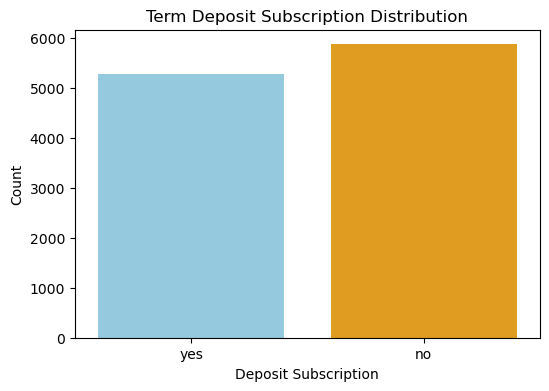

In [86]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='deposit',
    data=df,
    palette=['skyblue', 'orange']
)

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Deposit Subscription")
plt.ylabel("Count")

plt.show()

# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns, trends, and relationships within the dataset.

In this section, we analyze:
- Customer age distribution
- Job categories
- Marital status
- Subscription behavior

## 7.1 Age Distribution

We analyze how customer ages are distributed across the dataset.

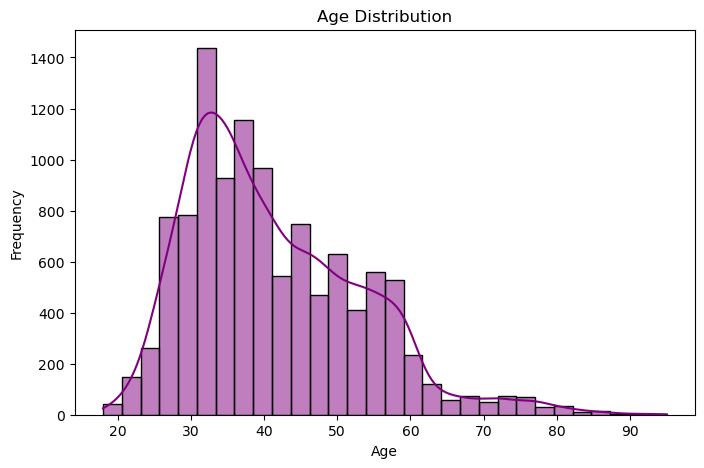

In [87]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## 7.2 Job Type vs Deposit Subscription

This visualization helps analyze how customers from different job categories respond to the marketing campaign.

plt.figure(figsize=(14,6))

sns.countplot(
    x='job',
    hue='deposit',
    data=df,
    palette=['tomato', 'seagreen']
)

plt.title("Job Type vs Deposit Subscription")
plt.xlabel("Job Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## 7.3 Marital Status vs Deposit Subscription

We analyze whether marital status influences a customer's likelihood of subscribing to a term deposit.

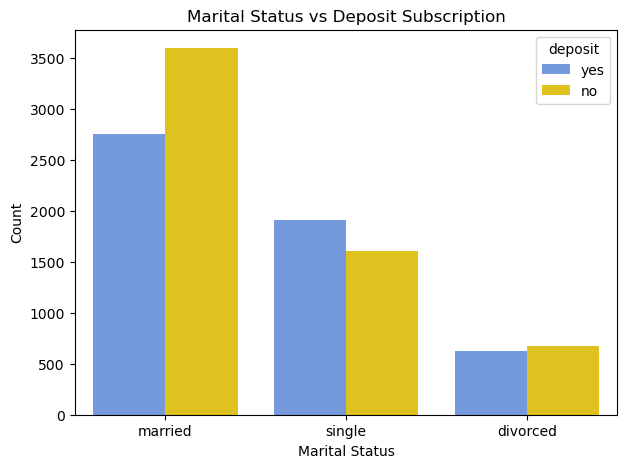

In [88]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='marital',
    hue='deposit',
    data=df,
    palette=['cornflowerblue', 'gold']
)

plt.title("Marital Status vs Deposit Subscription")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.show()

## 7.4 Education Level vs Deposit Subscription

This analysis helps us understand how education level relates to subscription behavior.

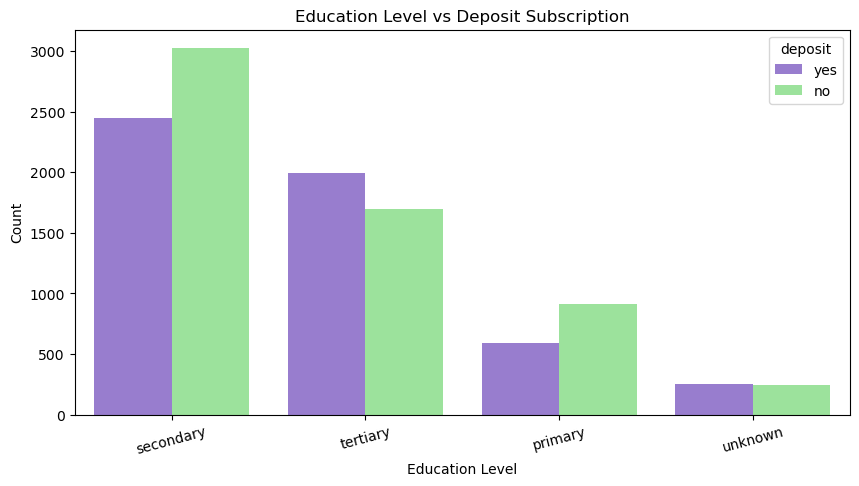

In [89]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='education',
    hue='deposit',
    data=df,
    palette=['mediumpurple', 'lightgreen']
)

plt.title("Education Level vs Deposit Subscription")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

## 7.5 Account Balance Distribution

We analyze customer account balances to understand spending and financial distribution patterns.

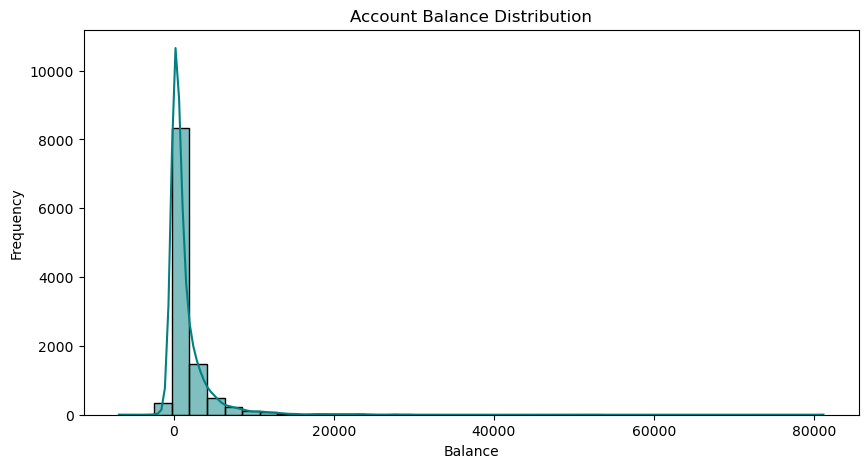

In [90]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['balance'],
    bins=40,
    kde=True,
    color='teal'
)

plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

## 7.6 Correlation Analysis

Correlation analysis helps identify relationships between numerical variables in the dataset.

A heatmap provides a visual representation of these correlations.

In [91]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

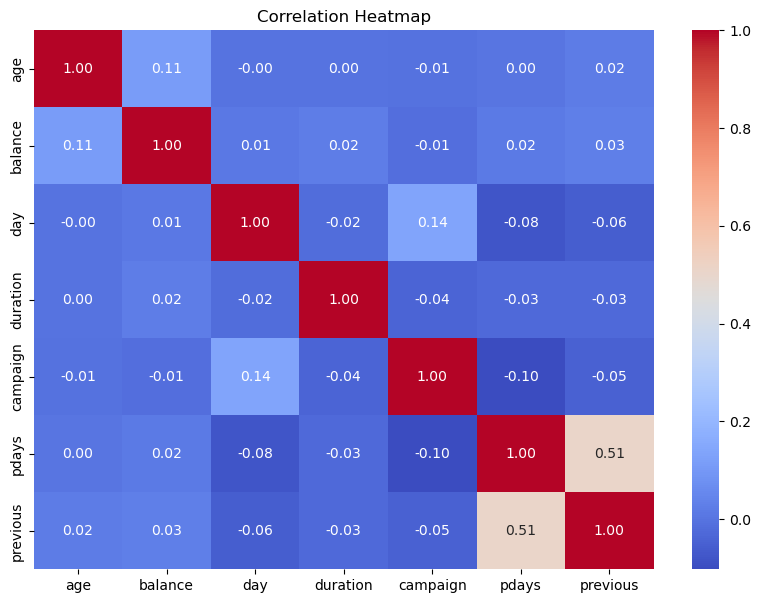

In [92]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

# 8. Data Preprocessing

Machine learning models require numerical input data.

In this step:
- Categorical features are converted into numerical values
- Label Encoding is applied to object-type columns

## 8.1 Checking Data Types

We identify categorical and numerical columns before encoding.

In [93]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

## 8.2 Encoding Categorical Variables

Categorical variables are converted into numerical form using Label Encoding.

This transformation allows machine learning algorithms to process the data.

In [94]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [95]:
for col in df.columns:
    
    if df[col].dtype == 'object':
        
        df[col] = le.fit_transform(df[col])

## 8.3 Encoded Dataset Preview

We verify that all categorical variables have been successfully converted into numerical values.

In [96]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


# 9. Feature and Target Separation

Machine learning models require:
- Input features (`X`)
- Target variable (`y`)

Here:
- `X` contains customer information
- `y` contains deposit subscription outcomes

In [97]:
X = df.drop('deposit', axis=1)

y = df['deposit']

# 10. Train-Test Split

The dataset is divided into:
- Training data (80%)
- Testing data (20%)

This allows us to train the model on one portion of the data and evaluate it on unseen data.

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 11. Logistic Regression Model

Logistic Regression is a commonly used binary classification algorithm.

It predicts whether a customer is likely to subscribe to a term deposit.

In [100]:
from sklearn.linear_model import LogisticRegression

In [101]:
lr_model = LogisticRegression()

In [102]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 12. Logistic Regression Predictions

After training the model, we generate predictions on the test dataset.

In [103]:
lr_pred = lr_model.predict(X_test)

# 13. Logistic Regression Evaluation

We evaluate the model using:
- Classification Report
- Confusion Matrix
- F1 Score

These metrics help measure model performance.

## 13.1 Classification Report

The classification report includes:
- Precision
- Recall
- F1-score
- Accuracy

In [104]:
from sklearn.metrics import classification_report

In [105]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.75      0.78      0.77      1166
           1       0.75      0.71      0.73      1067

    accuracy                           0.75      2233
   macro avg       0.75      0.75      0.75      2233
weighted avg       0.75      0.75      0.75      2233



## 13.2 Confusion Matrix

A confusion matrix shows:
- Correct predictions
- Incorrect predictions
- False positives
- False negatives

In [106]:
from sklearn.metrics import confusion_matrix

In [107]:
cm = confusion_matrix(y_test, lr_pred)

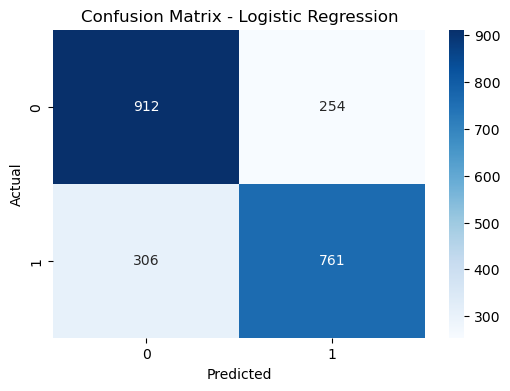

In [108]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 13.3 F1 Score

F1-score balances:
- Precision
- Recall

It is especially useful for imbalanced classification datasets.

In [109]:
from sklearn.metrics import f1_score

In [110]:
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression F1 Score:", lr_f1)

Logistic Regression F1 Score: 0.7310278578290106


# 14. ROC Curve and AUC Score

The ROC Curve evaluates the model's ability to distinguish between classes.

AUC (Area Under the Curve):
- closer to 1 → better model performance
- closer to 0.5 → weak model

## 14.1 Predicting Probabilities

ROC Curve requires prediction probabilities instead of class labels.

In [111]:
y_prob = lr_model.predict_proba(X_test)[:, 1]

## 14.2 Calculating ROC Metrics

We calculate:
- False Positive Rate (FPR)
- True Positive Rate (TPR)
- AUC Score

In [112]:
from sklearn.metrics import roc_curve, auc

In [113]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

## 14.3 ROC Curve Visualization

The ROC Curve visualizes the trade-off between:
- True Positive Rate
- False Positive Rate

A larger AUC indicates better classification performance.

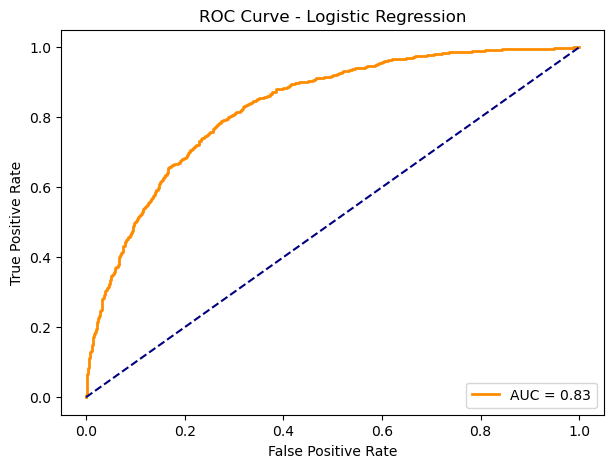

In [114]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    linewidth=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    color='navy',
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend(loc='lower right')

plt.show()

# 15. Random Forest Classification Model

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

## 15.1 Importing Random Forest Classifier

In [115]:
from sklearn.ensemble import RandomForestClassifier

## 15.2 Initializing the Random Forest Model

We create the Random Forest classifier with:
- 100 decision trees
- fixed random state for reproducibility

In [116]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

## 15.3 Training the Random Forest Model

The model is trained using the training dataset.

In [117]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 15.4 Random Forest Predictions

After training the model, predictions are generated using the test dataset.

In [118]:
rf_pred = rf_model.predict(X_test)

# 16. Random Forest Model Evaluation

We evaluate Random Forest performance using:
- Classification Report
- Confusion Matrix
- F1 Score

## 16.1 Classification Report

This report shows:
- Precision
- Recall
- F1-score
- Accuracy
    

In [119]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



## 16.2 Confusion Matrix

The confusion matrix helps visualize:
- Correct classifications
- Incorrect classifications
- Prediction errors

In [120]:
cm_rf = confusion_matrix(y_test, rf_pred)

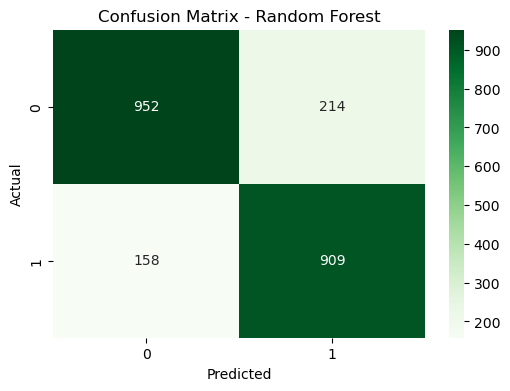

In [121]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 16.3 F1 Score

The F1-score provides a balance between:
- Precision
- Recall

It is especially important for imbalanced datasets.

In [122]:
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest F1 Score:", rf_f1)

Random Forest F1 Score: 0.8301369863013699


# 17. Feature Importance Analysis

Feature importance helps identify which variables most strongly influence the model’s predictions.

This insight is valuable for:
- Business understanding
- Decision-making
- Marketing strategy optimization

## 17.1 Extracting Feature Importance Scores

In [123]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

## 17.2 Sorting Features by Importance

Features are sorted from highest importance to lowest importance.

In [124]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
11,duration,0.374896
5,balance,0.086482
0,age,0.082545
10,month,0.082503
9,day,0.071500
8,contact,0.045690
13,pdays,0.042597
1,job,0.038083
15,poutcome,0.035686
12,campaign,0.033079


## 17.3 Feature Importance Visualization

This visualization highlights the most influential features used by the Random Forest model.

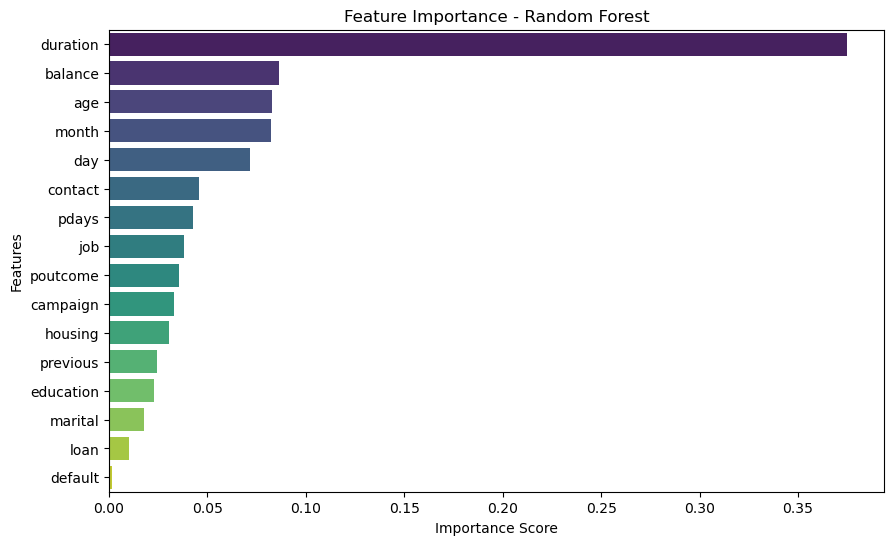

In [125]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette='viridis'
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# 18. Explainable AI using SHAP

SHAP (SHapley Additive exPlanations) helps explain:
- How the model makes predictions
- Which features influence predictions most
- Why a specific prediction was made

This improves model interpretability and transparency.

## 18.1 Initializing SHAP Explainer

We use TreeExplainer because Random Forest is a tree-based model.

In [126]:
explainer = shap.TreeExplainer(rf_model)

## 18.2 Generating SHAP Values

SHAP values measure the contribution of each feature toward model predictions.

In [131]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_sample)

## 18.3 SHAP Summary Plot

The SHAP summary plot shows:
- Most important features
- Positive and negative impacts
- Feature influence distribution

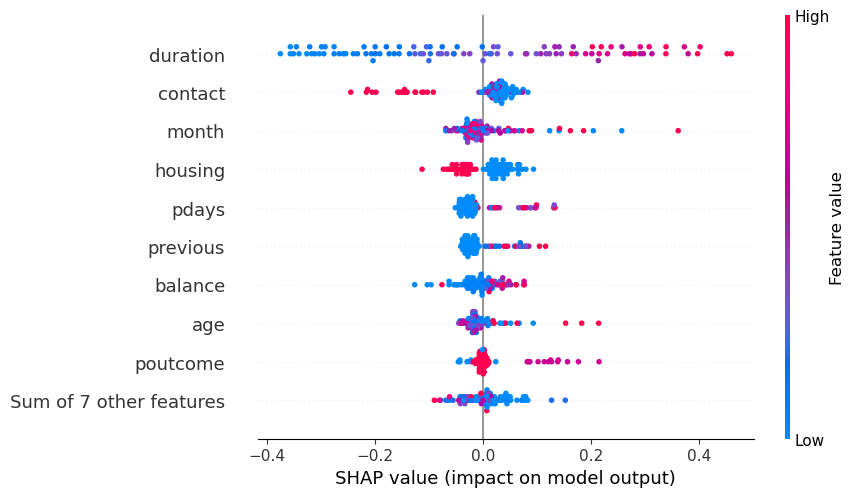

In [133]:
shap.plots.beeswarm(shap_values[:, :, 1])

## 18.4 Explaining Individual Predictions

We now explain specific customer predictions using SHAP waterfall plots.

These plots show:
- Features increasing subscription probability
- Features decreasing subscription probability
- Overall prediction contribution

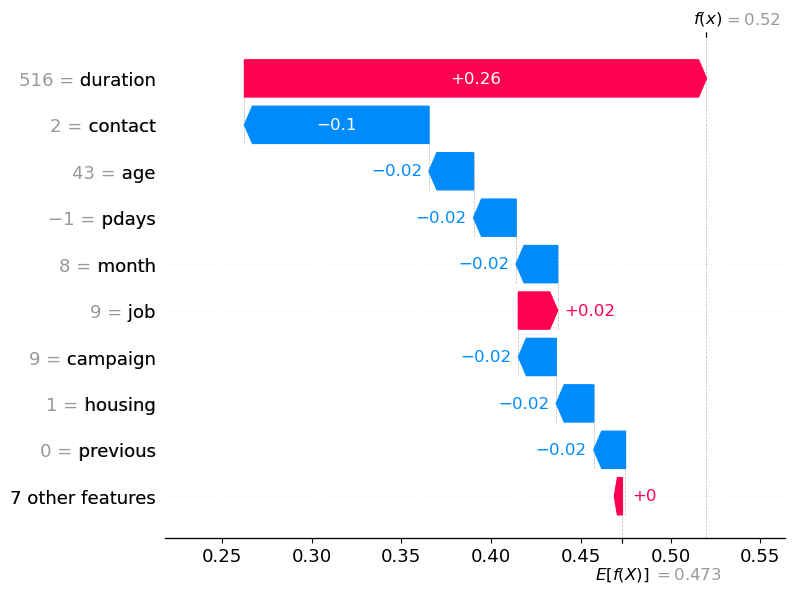

In [134]:
shap.plots.waterfall(shap_values[0, :, 1])

## 18.5 Explaining Multiple Predictions

Below are additional SHAP explanations for multiple customer predictions.

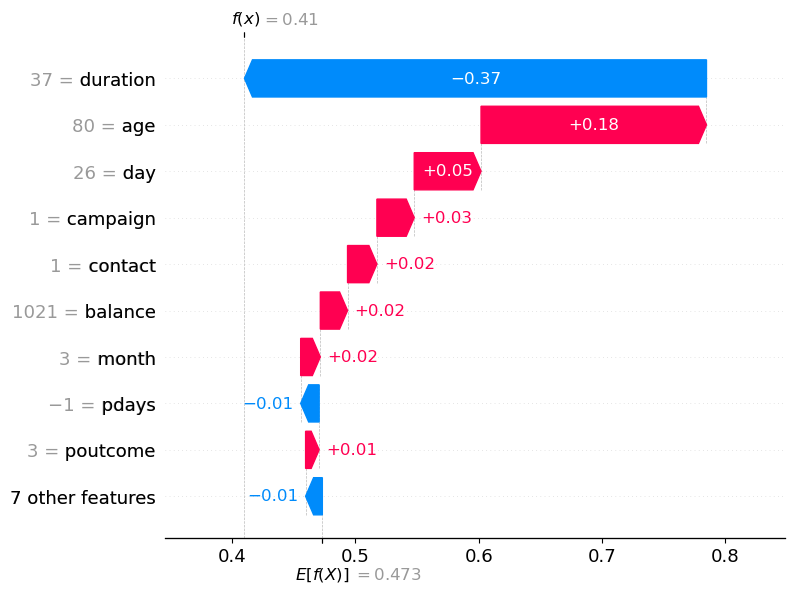

In [135]:
shap.plots.waterfall(shap_values[1, :, 1])

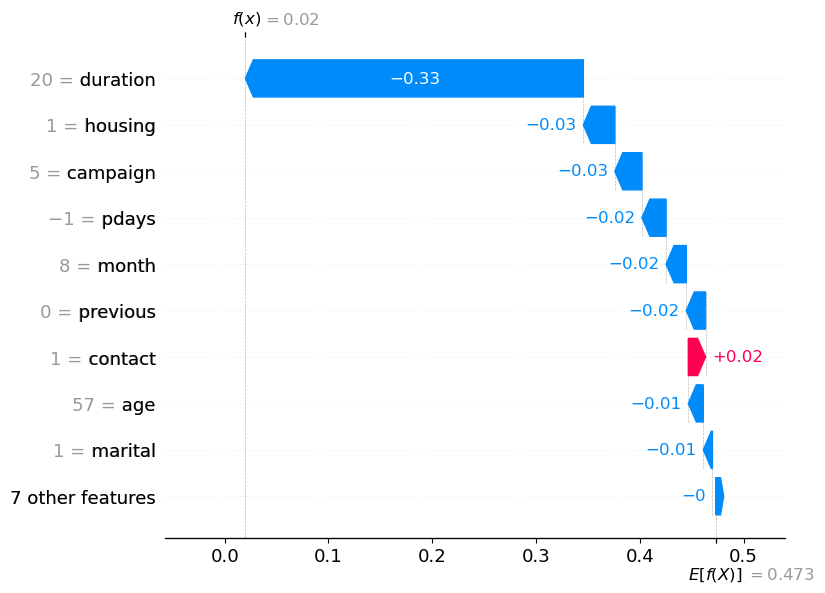

In [136]:
shap.plots.waterfall(shap_values[2, :, 1])

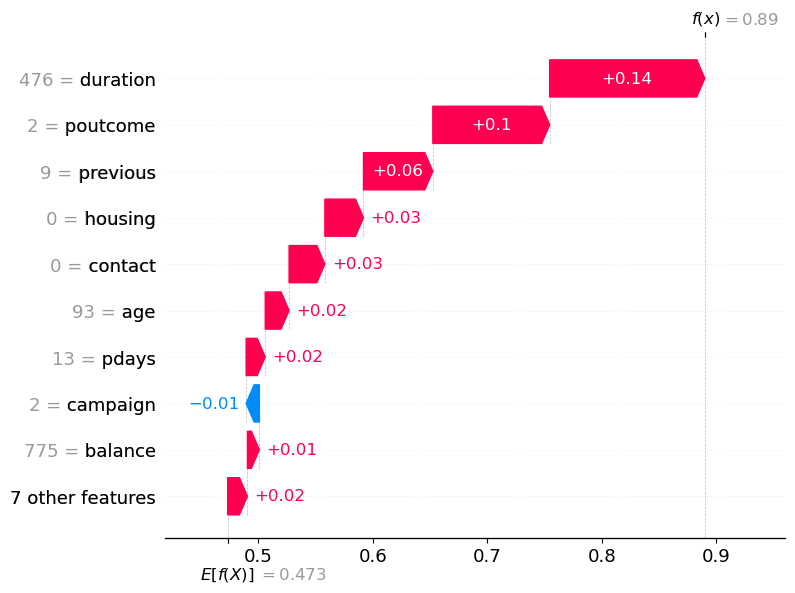

In [137]:
shap.plots.waterfall(shap_values[3, :, 1])

# 19. Conclusion

## Project Summary

This project focused on predicting whether a bank customer would subscribe to a term deposit using machine learning techniques.

The workflow included:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Logistic Regression modeling
- Random Forest classification
- Model evaluation
- Explainable AI using SHAP

---

## Key Findings

- Random Forest performed better than Logistic Regression in predicting customer subscriptions.
- Features such as:
  - duration
  - balance
  - age
  - campaign interactions
  had strong influence on predictions.
- SHAP analysis improved interpretability by explaining how features contributed to predictions.

---

## Business Insights

- The bank can use predictive modeling to identify high-potential customers.
- Marketing campaigns can be optimized to target customers with higher subscription probability.
- Better targeting can reduce marketing costs and improve conversion rates.

---

## Final Outcome

The project successfully demonstrated:
- Classification modeling
- Customer behavior analysis
- Explainable AI (XAI)
- Business-oriented machine learning applications